# Laboratorio 3 - Deep Learning

## Reconocimiento del Alfabeto ASL mediante Redes Neuronales Convolucionales

### CC3084 - Data Science

**Integrantes**

- Milton Polanco
- Osman de León

Semestre II - 2026

# 1. Introducción

El reconocimiento automático de imágenes es una de las áreas donde el Deep Learning ha tenido más impacto, porque permite construir sistemas que identifican patrones visuales con mucha precisión. Una de sus aplicaciones más interesantes es el reconocimiento del lenguaje de señas, que puede dar lugar a herramientas tecnológicas que faciliten la comunicación y mejoren la accesibilidad para personas con discapacidad auditiva.

En este laboratorio vamos a trabajar en un problema de clasificación de imágenes: reconocer las letras del alfabeto del Lenguaje de Señas Americano (ASL) usando el conjunto de datos ASL Alphabet. La idea es desarrollar un modelo que, al recibir una imagen de una mano, pueda identificar automáticamente qué letra está representando. |El proyecto lo vamos a dividir en varias etapas. Primero, haremos un análisis exploratorio de los datos para entender cómo están organizados, cómo se distribuyen las clases y qué características tienen las imágenes. Después, definiremos el preprocesamiento que les vamos a aplicar y elegiremos los modelos de aprendizaje automático y profundo que vamos a probar a lo largo del laboratorio.

# 2. Objetivos

## 2.1 Objetivo General

Desarrollar un sistema de clasificación de imágenes capaz de reconocer las letras del alfabeto del Lenguaje de Señas Americano (ASL), mediante técnicas de Deep Learning y aprendizaje automático, iniciando con el análisis exploratorio del conjunto de datos, el diseño del proceso de preprocesamiento y la selección de los modelos que serán implementados.

## 2.2 Objetivos Específicos

- Analizar la estructura y las características del conjunto de datos ASL Alphabet mediante un análisis exploratorio.
- Identificar la distribución de las clases, la resolución de las imágenes y las posibles similitudes visuales entre distintas letras del alfabeto.
- Definir un proceso de preprocesamiento adecuado para preparar las imágenes antes del entrenamiento de los modelos.
- Seleccionar los modelos de aprendizaje profundo y aprendizaje automático que serán implementados y comparados durante el desarrollo del laboratorio.
- Establecer un plan de trabajo para el procesamiento de las imágenes y el entrenamiento de los modelos en las siguientes etapas del proyecto.

# 3. Configuración del Entorno

En esta sección se importan las librerías necesarias para el desarrollo del laboratorio, se descarga automáticamente el conjunto de datos (en caso de no encontrarse de forma local) y se definen las rutas que serán utilizadas durante el análisis exploratorio y las etapas posteriores del proyecto.

## 3.1 Importación de Librerías

In [2]:
# ==========================================
# Librerías estándar
# ==========================================
import sys
from pathlib import Path
from collections import Counter

# Agregar la carpeta raíz del proyecto al PATH
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# ==========================================
# Manipulación de datos
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# Visualización
# ==========================================
import matplotlib.pyplot as plt

# ==========================================
# Procesamiento de imágenes
# ==========================================
from PIL import Image

# ==========================================
# Machine Learning / Deep Learning
# ==========================================
import tensorflow as tf

# ==========================================
# Utilidades
# ==========================================
from src.download_dataset import ensure_dataset

## 3.2 Descarga y Carga del Dataset

El conjunto de datos utilizado en este laboratorio se encuentra almacenado en Google Drive. Para facilitar la reproducibilidad del proyecto, se implementó un script que verifica si el dataset ya existe localmente. En caso contrario, este se descarga automáticamente, se descomprime y queda listo para ser utilizado.

In [3]:
DATASET_PATH = ensure_dataset()

✅ Dataset encontrado.



## 3.3 Definición de Rutas de Trabajo

Se definen las rutas principales del proyecto para acceder a los conjuntos de entrenamiento y prueba.

In [4]:
TRAIN_PATH = DATASET_PATH / "train"
TEST_PATH = DATASET_PATH / "test"

print(f"Dataset : {DATASET_PATH}")
print(f"Train   : {TRAIN_PATH}")
print(f"Test    : {TEST_PATH}")

Dataset : C:\Users\Emadlg\Desktop\UVG\Cuarto Año\Segundo Ciclo\Data Science\Data_Science\Lab-DeepLearning\dataset
Train   : C:\Users\Emadlg\Desktop\UVG\Cuarto Año\Segundo Ciclo\Data Science\Data_Science\Lab-DeepLearning\dataset\train
Test    : C:\Users\Emadlg\Desktop\UVG\Cuarto Año\Segundo Ciclo\Data Science\Data_Science\Lab-DeepLearning\dataset\test


## 3.4 Verificación del Dataset

Antes de comenzar el análisis exploratorio, se verifica que las carpetas principales del conjunto de datos se encuentren disponibles.

In [5]:
print(f"Número de carpetas en Train: {len(list(TRAIN_PATH.iterdir()))}")
print(f"Número de imágenes en Test: {len(list(TEST_PATH.glob('*')))}")

Número de carpetas en Train: 29
Número de imágenes en Test: 28


# 4. Análisis Exploratorio de Datos (EDA)

Antes de entrenar cualquier modelo de aprendizaje automático o Deep Learning, es importante comprender las características del conjunto de datos. En esta sección se analiza la estructura del dataset, la distribución de las clases, las propiedades de las imágenes y algunas características visuales relevantes para el problema de clasificación.

## 4.1 Estructura del Dataset

In [6]:
print("Estructura del conjunto de entrenamiento:\n")

for carpeta in sorted(TRAIN_PATH.iterdir()):
    if carpeta.is_dir():
        print(f"📁 {carpeta.name}")

Estructura del conjunto de entrenamiento:

📁 A
📁 B
📁 C
📁 D
📁 del
📁 E
📁 F
📁 G
📁 H
📁 I
📁 J
📁 K
📁 L
📁 M
📁 N
📁 nothing
📁 O
📁 P
📁 Q
📁 R
📁 S
📁 space
📁 T
📁 U
📁 V
📁 W
📁 X
📁 Y
📁 Z


### Observación

El conjunto de entrenamiento se encuentra organizado en carpetas, donde cada carpeta representa una clase distinta del problema de clasificación. Cada imagen almacenada dentro de una carpeta corresponde a un ejemplo de la seña asociada a esa clase.

Además de las 26 letras del alfabeto, el dataset incorpora tres clases adicionales (`space`, `del` y `nothing`), utilizadas para representar acciones comunes dentro de aplicaciones de reconocimiento de lenguaje de señas.

## 4.2 Clases Disponibles

In [7]:
classes = sorted(
    [
        folder.name
        for folder in TRAIN_PATH.iterdir()
        if folder.is_dir()
    ]
)

print(f"Número de clases: {len(classes)}\n")

print(classes)

Número de clases: 29

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 4.3 Cantidad de Imágenes por Clase

En esta sección se contabiliza el número de imágenes disponibles para cada clase del conjunto de entrenamiento. Esta información permitirá verificar si el dataset se encuentra balanceado y servirá como base para las visualizaciones posteriores.

In [8]:
dataset_info = []

for class_name in classes:

    class_path = TRAIN_PATH / class_name

    num_images = len(list(class_path.glob("*")))

    dataset_info.append({
        "Clase": class_name,
        "Cantidad de imágenes": num_images
    })

dataset_df = pd.DataFrame(dataset_info)

dataset_df

,Clase,Cantidad de imágenes
0,A,3000
1,B,3000
2,C,3000
3,D,3000
4,E,3000
5,F,3000
6,G,3000
7,H,3000
8,I,3000
9,J,3000


### Observación

La tabla anterior resume la cantidad de imágenes disponibles para cada una de las clases presentes en el conjunto de entrenamiento. Esta información será utilizada para analizar la distribución del dataset y determinar si existe un desbalance entre las distintas categorías.

## 4.4 Distribución de Clases

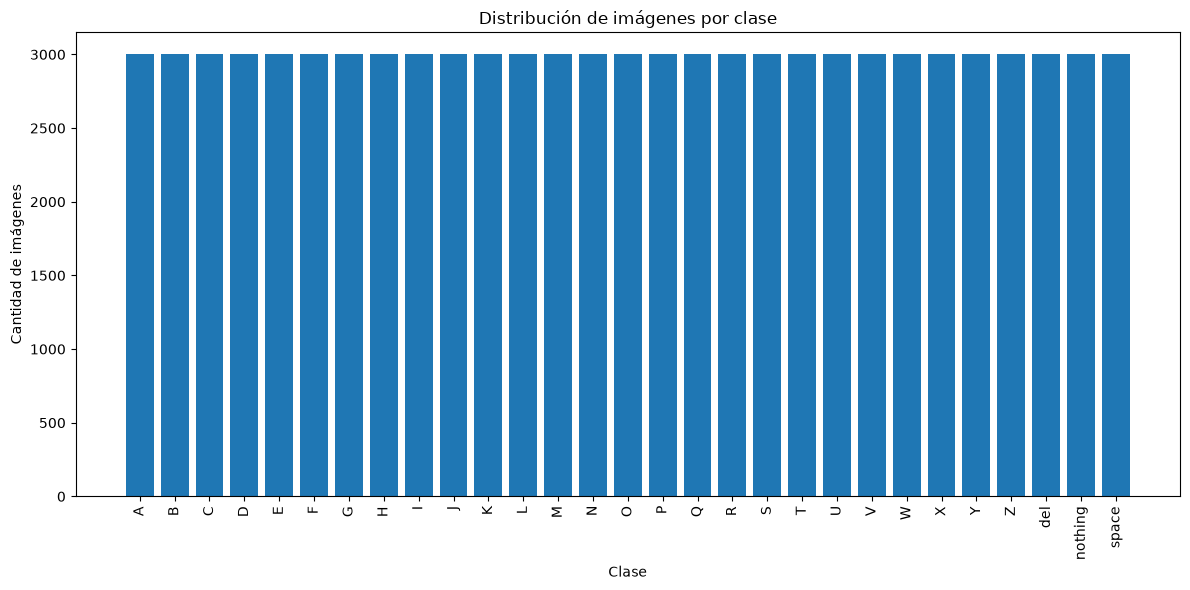

In [9]:
plt.figure(figsize=(12,6))

plt.bar(
    dataset_df["Clase"],
    dataset_df["Cantidad de imágenes"]
)

plt.title("Distribución de imágenes por clase")

plt.xlabel("Clase")

plt.ylabel("Cantidad de imágenes")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

### Análisis

A partir de la gráfica se puede evaluar si el conjunto de datos presenta un número similar de imágenes por clase. Un dataset balanceado reduce la posibilidad de que el modelo favorezca determinadas clases durante el entrenamiento, permitiendo que el proceso de aprendizaje sea más uniforme.

## 4.5 Estadísticas Generales del Dataset

In [10]:
print(f"Número total de clases: {len(dataset_df)}")

print(f"Número total de imágenes: {dataset_df['Cantidad de imágenes'].sum()}")

print(f"Promedio de imágenes por clase: {dataset_df['Cantidad de imágenes'].mean():.2f}")

print(f"Mínimo de imágenes por clase: {dataset_df['Cantidad de imágenes'].min()}")

print(f"Máximo de imágenes por clase: {dataset_df['Cantidad de imágenes'].max()}")

Número total de clases: 29
Número total de imágenes: 87000
Promedio de imágenes por clase: 3000.00
Mínimo de imágenes por clase: 3000
Máximo de imágenes por clase: 3000


## 4.6 Resolución y Formato de las Imágenes

Antes de definir el proceso de preprocesamiento, es importante conocer las características de las imágenes presentes en el dataset. Para ello se analizarán aspectos como la resolución, el formato del archivo y el modo de color utilizado.

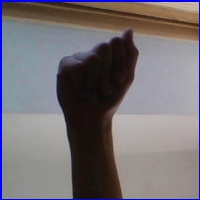

In [12]:
sample_image_path = next((TRAIN_PATH / "A").glob("*"))

sample_image = Image.open(sample_image_path)

sample_image

In [13]:
print(f"Nombre del archivo : {sample_image_path.name}")

print(f"Formato            : {sample_image.format}")

print(f"Modo de color      : {sample_image.mode}")

print(f"Resolución         : {sample_image.size[0]} x {sample_image.size[1]} píxeles")

Nombre del archivo : A1.jpg
Formato            : JPEG
Modo de color      : RGB
Resolución         : 200 x 200 píxeles


### Análisis

Las imágenes del conjunto de datos se encuentran almacenadas en formato **JPEG**, poseen una resolución de **200 × 200 píxeles** y utilizan el espacio de color **RGB**. Estas características permiten trabajar con imágenes a color, aunque para reducir el tiempo de entrenamiento será conveniente disminuir su resolución durante el proceso de preprocesamiento.

## 4.7 Visualización de Muestras

### 4.7.1 Ejemplos de distintas letras

A continuación se presentan ejemplos de diferentes clases del conjunto de datos con el objetivo de observar las distintas señas que deberá aprender el modelo.

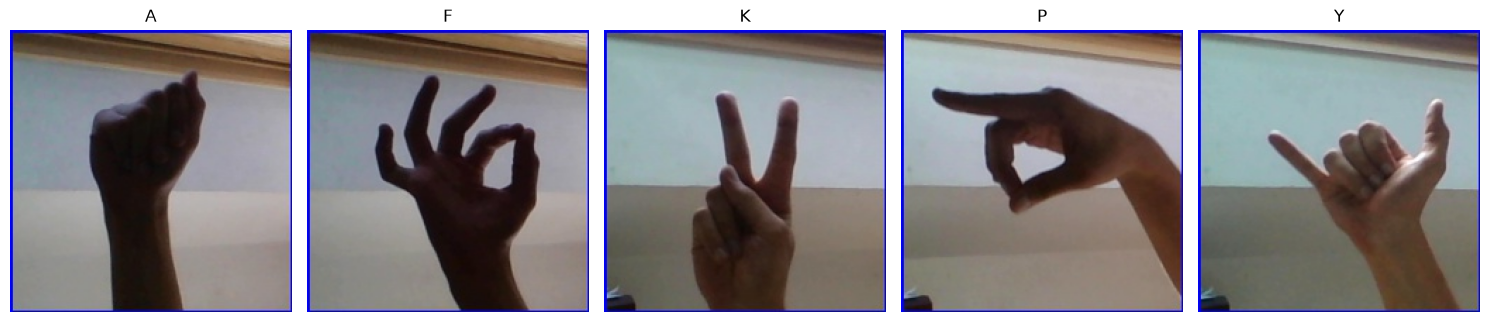

In [14]:
letters = ["A", "F", "K", "P", "Y"]

fig, axes = plt.subplots(1, 5, figsize=(15,5))

for ax, letter in zip(axes, letters):

    image_path = next((TRAIN_PATH / letter).glob("*"))

    image = Image.open(image_path)

    ax.imshow(image)

    ax.set_title(letter)

    ax.axis("off")

plt.tight_layout()

plt.show()

### 4.7.2 Variabilidad dentro de una misma clase

Además de visualizar distintas clases, resulta importante analizar la variabilidad existente entre imágenes pertenecientes a una misma categoría. Aunque todas representan la misma letra, pueden existir diferencias en la posición de la mano, iluminación, orientación y pequeñas variaciones que el modelo deberá aprender a reconocer.

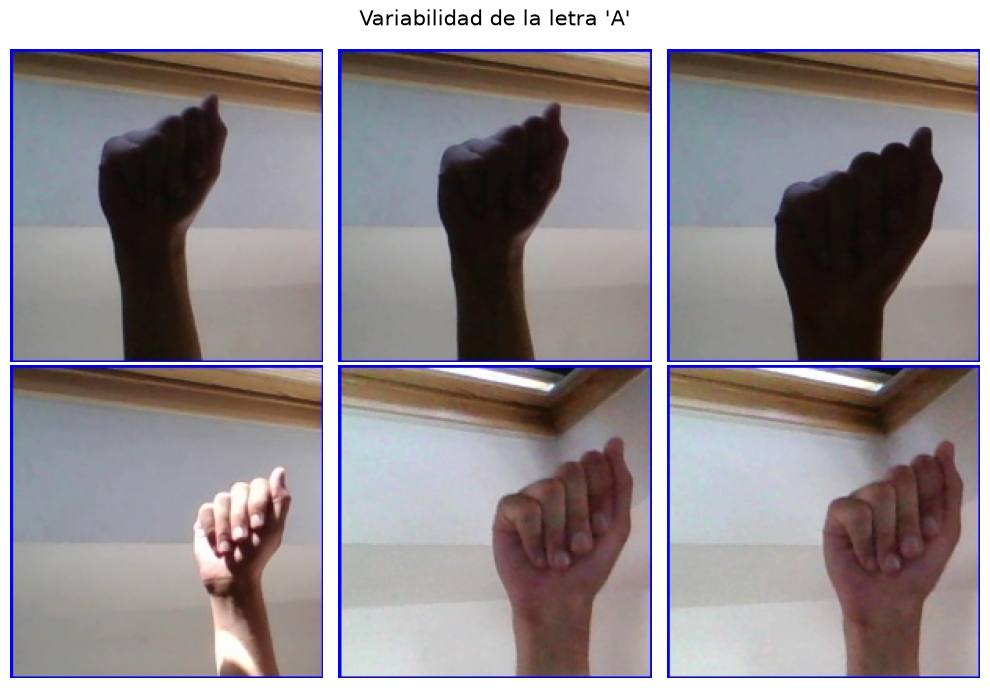

In [15]:
letter = "A"

images = list((TRAIN_PATH / letter).glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(10,7))

for ax, image_path in zip(axes.ravel(), images):

    image = Image.open(image_path)

    ax.imshow(image)

    ax.axis("off")

plt.suptitle(f"Variabilidad de la letra '{letter}'", fontsize=15)

plt.tight_layout()

plt.show()

### Análisis

Para preparar los datos para el entrenamiento se utilizó la función
`image_dataset_from_directory()` de TensorFlow, la cual permite cargar
automáticamente las imágenes organizadas por carpetas y asignar las etiquetas
correspondientes a cada clase.

Durante este proceso se configuró una resolución de entrada de **64 × 64 píxeles**,
un tamaño de lote (**batch size**) de **32 imágenes** y una semilla (`seed = 42`)
para garantizar que la división de los datos sea reproducible en cada ejecución.

En esta etapa únicamente se prepararon los conjuntos de entrenamiento y validación.
El conjunto de prueba será definido durante la implementación de los modelos, con el
fin de mantener una separación adecuada entre los datos utilizados para entrenar y los
empleados para evaluar el desempeño final.

### 4.7.3 Letras Visualmente Similares

Algunas letras del alfabeto ASL presentan configuraciones de la mano muy parecidas entre sí, lo que representa un desafío para cualquier modelo de clasificación. En esta sección se muestran algunos ejemplos de letras con características visuales similares para identificar posibles fuentes de confusión durante el entrenamiento.

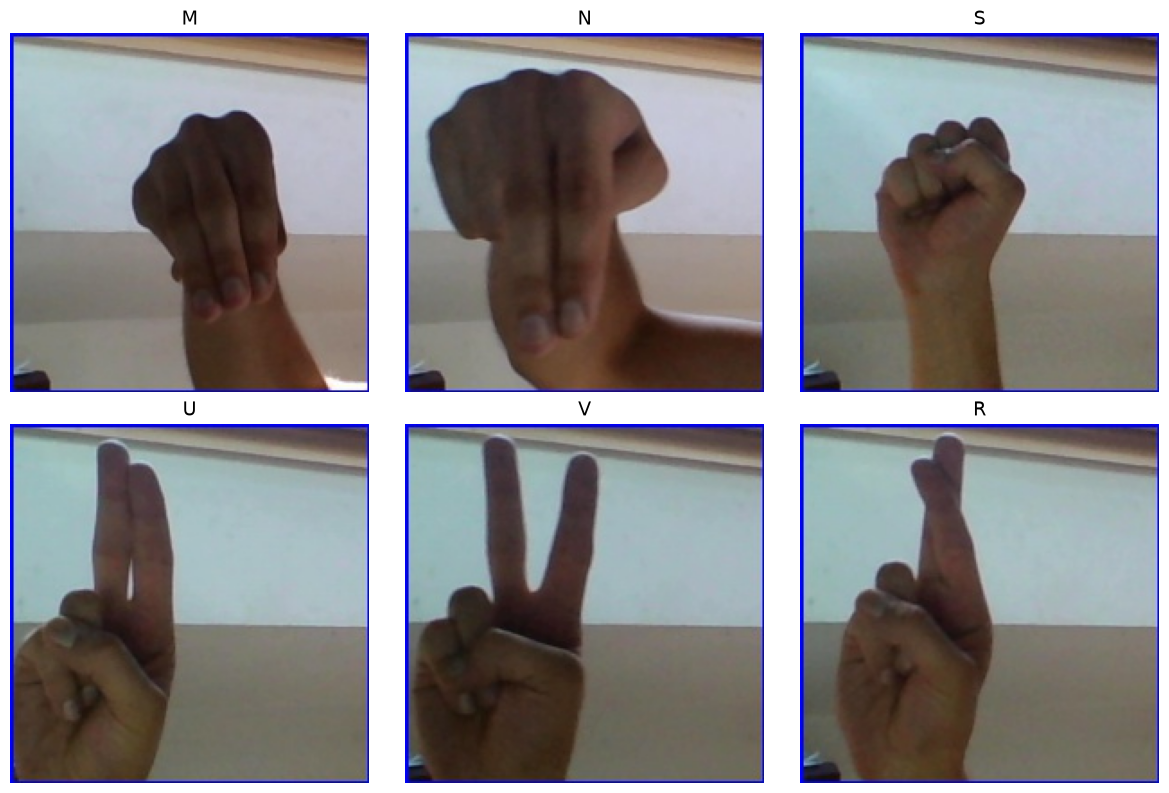

In [16]:
similar_letters = ["M", "N", "S", "U", "V", "R"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, letter in zip(axes.ravel(), similar_letters):

    image_path = next((TRAIN_PATH / letter).glob("*.jpg"))

    image = Image.open(image_path)

    ax.imshow(image)

    ax.set_title(letter, fontsize=14)

    ax.axis("off")

plt.tight_layout()

plt.show()

### Análisis

A simple vista es posible identificar grupos de letras que presentan configuraciones muy similares de la mano. Por ejemplo, las letras **M**, **N** y **S** comparten una postura cerrada de los dedos, mientras que **U**, **V** y **R** difieren únicamente en la separación o cruce de algunos dedos.

Estas similitudes pueden incrementar la dificultad del problema de clasificación, ya que pequeñas variaciones en el ángulo de captura, la iluminación o la posición de la mano podrían hacer que dos clases sean visualmente muy parecidas. Por esta razón, será importante utilizar modelos capaces de aprender características espaciales complejas, como las Redes Neuronales Convolucionales (CNN).

## 4.8 División del Conjunto de Datos

El conjunto de datos original proporciona un conjunto de entrenamiento y un conjunto de prueba con muy pocas imágenes. Debido a ello, se construirá un nuevo conjunto de entrenamiento, validación y prueba a partir de las imágenes disponibles en la carpeta de entrenamiento, con el objetivo de obtener una evaluación más representativa del desempeño de los modelos.

### Estrategia de División

Para el desarrollo de este laboratorio se utilizará la siguiente distribución:

- **70 %** para entrenamiento.
- **15 %** para validación.
- **15 %** para prueba.

Esta división permitirá disponer de suficientes ejemplos para entrenar los modelos, ajustar sus hiperparámetros mediante el conjunto de validación y evaluar objetivamente su desempeño utilizando datos que no fueron observados durante el entrenamiento.

### Distribución Propuesta

| Conjunto | Porcentaje |
|-----------|-----------:|
| Entrenamiento | 70 % |
| Validación | 15 % |
| Prueba | 15 % |

In [17]:
total_images = dataset_df["Cantidad de imágenes"].sum()

train_size = int(total_images * 0.70)
validation_size = int(total_images * 0.15)
test_size = total_images - train_size - validation_size

division_df = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "Porcentaje": ["70 %", "15 %", "15 %"],
    "Cantidad de imágenes": [
        train_size,
        validation_size,
        test_size
    ]
})

division_df

,Conjunto,Porcentaje,Cantidad de imágenes
0,Entrenamiento,70 %,60899
1,Validación,15 %,13050
2,Prueba,15 %,13051


### Análisis

La división propuesta garantiza que el conjunto de entrenamiento disponga de una cantidad suficiente de imágenes para aprender patrones representativos de cada clase. Asimismo, los conjuntos de validación y prueba permitirán evaluar el desempeño de los modelos y verificar su capacidad de generalización sobre imágenes que no fueron utilizadas durante el entrenamiento.

# 5. Preprocesamiento

El preprocesamiento constituye una etapa fundamental antes del entrenamiento de los modelos de aprendizaje automático y Deep Learning. Su objetivo es preparar las imágenes para que los algoritmos puedan aprender de forma más eficiente, reduciendo el costo computacional y manteniendo la información relevante para el reconocimiento de las señas.

## 5.1 Justificación del Preprocesamiento

Las imágenes originales poseen una resolución de **200 × 200 píxeles** en formato RGB. Aunque esta resolución proporciona un alto nivel de detalle, también incrementa considerablemente el costo computacional durante el entrenamiento.

Por ello, se propone reducir la resolución de las imágenes, normalizar sus valores de intensidad y dividir adecuadamente el conjunto de datos antes de entrenar los modelos. Estas transformaciones permitirán disminuir el tiempo de entrenamiento sin perder las características más importantes de las señas.

## 5.2 Cambio de Resolución

In [18]:
sample_image_path = next((TRAIN_PATH / "A").glob("*.jpg"))

original_image = Image.open(sample_image_path)

resized_image = original_image.resize((64, 64))

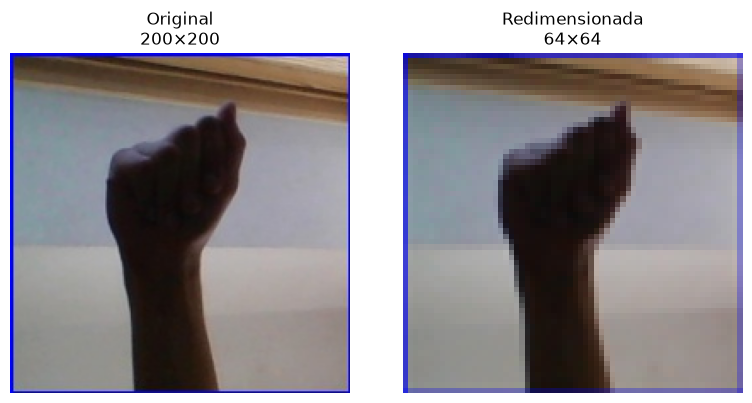

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].imshow(original_image)
axes[0].set_title(f"Original\n{original_image.width}×{original_image.height}")
axes[0].axis("off")

axes[1].imshow(resized_image)
axes[1].set_title(f"Redimensionada\n{resized_image.width}×{resized_image.height}")
axes[1].axis("off")

plt.tight_layout()

plt.show()

### Análisis

Se propone reducir la resolución de las imágenes de **200 × 200 píxeles** a **64 × 64 píxeles**, con el objetivo de disminuir el costo computacional y acelerar el entrenamiento de los modelos.

Como puede observarse, la reducción de resolución produce una pérdida de detalle en la imagen, especialmente en los contornos y la definición de los dedos. Sin embargo, la forma general de la mano y la postura correspondiente a la seña aún se conservan, por lo que se considera una resolución adecuada como punto de partida para el entrenamiento. En etapas posteriores se evaluará si esta reducción afecta significativamente el desempeño de los modelos.

## 5.3 Normalización

Las imágenes digitales almacenan la intensidad de cada píxel con valores enteros entre **0** y **255** para cada canal de color. Antes de entrenar los modelos, estos valores serán normalizados al intervalo **[0,1]**, lo que favorece la estabilidad del entrenamiento y facilita la convergencia de las redes neuronales.

In [20]:
image_array = np.array(original_image)

print("Valor mínimo:", image_array.min())
print("Valor máximo:", image_array.max())

Valor mínimo: 0
Valor máximo: 255


In [21]:
normalized_image = image_array / 255.0

print("Valor mínimo:", normalized_image.min())
print("Valor máximo:", normalized_image.max())

Valor mínimo: 0.0
Valor máximo: 1.0


### Análisis

La normalización transforma los valores de intensidad de los píxeles desde el intervalo **[0,255]** al intervalo **[0,1]**. Esta transformación evita que los modelos trabajen con valores numéricos muy grandes y contribuye a un entrenamiento más estable y eficiente, especialmente en redes neuronales profundas.

## 5.4 Creación de los Conjuntos de Entrenamiento, Validación y Prueba

Una vez definidas las transformaciones que serán aplicadas a las imágenes, se prepararán los conjuntos de entrenamiento y validación utilizando las herramientas proporcionadas por TensorFlow. Durante esta etapa también se establecerán parámetros como la resolución de entrada y el tamaño de los lotes (*batch size*), los cuales serán utilizados por los modelos de Deep Learning.

In [22]:
# ==========================================
# Parámetros de preprocesamiento
# ==========================================

IMAGE_SIZE = (64, 64)

BATCH_SIZE = 32

SEED = 42

VALIDATION_SPLIT = 0.15

### Creación del Conjunto de Entrenamiento

In [23]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 87000 files belonging to 29 classes.
Using 73950 files for training.


### Creación del Conjunto de Validación

In [24]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 87000 files belonging to 29 classes.
Using 13050 files for validation.


In [25]:
print("Clases:")

print(train_dataset.class_names)

Clases:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [26]:
print(f"Número de clases: {len(train_dataset.class_names)}")

Número de clases: 29


### Análisis

Los conjuntos de entrenamiento y validación fueron creados utilizando TensorFlow, manteniendo una separación reproducible mediante una semilla fija (`seed = 42`). Además, todas las imágenes fueron redimensionadas a **64 × 64 píxeles** y organizadas en lotes de **32 imágenes**, configuración que será utilizada durante el entrenamiento de los modelos.

El conjunto de prueba será construido posteriormente a partir de los datos disponibles, con el objetivo de disponer de una evaluación más representativa que la proporcionada por el conjunto de prueba original del dataset.

# 6. Selección de Modelos

Con base en las características del problema y del conjunto de datos, se seleccionaron diferentes modelos que serán implementados y comparados durante las siguientes etapas del laboratorio. El objetivo es analizar el comportamiento de distintas técnicas de clasificación de imágenes y determinar cuál ofrece el mejor desempeño para el reconocimiento de señas del alfabeto ASL.

## 6.1 Modelo CNN Base

Como primer modelo se implementará una Red Neuronal Convolucional (CNN) sencilla. Este modelo servirá como línea base para evaluar el desempeño inicial del problema de clasificación.

La arquitectura estará compuesta por capas convolucionales, funciones de activación ReLU, capas de agrupamiento (*MaxPooling*) y capas densas para la clasificación final de las 29 clases del dataset.

## 6.2 Modelo CNN Mejorado

Posteriormente se implementará una segunda CNN con una arquitectura más profunda y mayor capacidad de aprendizaje.

Se evaluarán diferentes configuraciones de hiperparámetros, tales como el número de filtros, cantidad de capas convolucionales, funciones de activación y mecanismos de regularización, con el objetivo de mejorar el desempeño obtenido por el modelo base.

## 6.3 Red Neuronal Fully Connected

Como punto de comparación se implementará una red neuronal tradicional (Fully Connected), la cual recibirá las imágenes transformadas en vectores unidimensionales.

Este modelo permitirá comparar el desempeño de una arquitectura convencional frente a las Redes Neuronales Convolucionales, las cuales están especialmente diseñadas para el procesamiento de imágenes.

## 6.4 Modelo Clásico de Machine Learning

Finalmente se implementará un modelo clásico de aprendizaje automático, como Support Vector Machine (SVM), Random Forest o K-Nearest Neighbors (KNN).

La inclusión de este modelo permitirá comparar algoritmos tradicionales con técnicas de Deep Learning y analizar las ventajas y limitaciones de cada enfoque para el reconocimiento de imágenes.

## 6.5 Justificación de la Selección

Los modelos seleccionados permiten comparar diferentes enfoques para resolver el problema de clasificación de imágenes.

Las Redes Neuronales Convolucionales constituyen el enfoque principal debido a su capacidad para aprender automáticamente características espaciales presentes en las imágenes. La red Fully Connected servirá como referencia para evidenciar las ventajas de utilizar arquitecturas especializadas para visión por computadora. Finalmente, el modelo clásico permitirá establecer una comparación con técnicas tradicionales de aprendizaje automático.

# 7. Plan para el Procesamiento de Imágenes

En las siguientes etapas del laboratorio se desarrollará un flujo de procesamiento orientado al entrenamiento y evaluación de diferentes modelos de clasificación de imágenes. El objetivo de este proceso es preparar adecuadamente el conjunto de datos, entrenar distintos modelos y comparar su desempeño para seleccionar la alternativa con mejores resultados.

## 7.1 Flujo de Trabajo

El proceso de desarrollo del proyecto seguirá las siguientes etapas:

1. Carga automática del conjunto de datos.
2. Análisis exploratorio de las imágenes.
3. Preprocesamiento de las imágenes.
4. División de los datos en entrenamiento, validación y prueba.
5. Entrenamiento de los diferentes modelos.
6. Evaluación mediante métricas de desempeño.
7. Comparación de resultados.
8. Selección del mejor modelo.
9. Pruebas con imágenes propias.
10. Análisis de resultados y conclusiones.

## 7.2 Estrategia de Entrenamiento

Durante el entrenamiento se evaluarán diferentes arquitecturas de redes neuronales convolucionales, así como una red neuronal completamente conectada y un modelo clásico de aprendizaje automático.

Todos los modelos serán entrenados utilizando el mismo conjunto de datos preprocesado para garantizar una comparación justa de su desempeño. Asimismo, se evaluará el impacto de distintas configuraciones de hiperparámetros con el objetivo de seleccionar la arquitectura que ofrezca los mejores resultados.

## 7.3 Métricas de Evaluación

El desempeño de los modelos será evaluado mediante diferentes métricas de clasificación, entre las cuales se consideran:

- Exactitud (*Accuracy*).
- Precisión (*Precision*).
- Sensibilidad (*Recall*).
- Puntaje F1 (*F1-Score*).
- Matriz de confusión.

Estas métricas permitirán analizar el comportamiento de los modelos y determinar cuál ofrece el mejor equilibrio entre capacidad de generalización y precisión en la clasificación de las señas.

## 7.4 Resultados Esperados

Se espera que las Redes Neuronales Convolucionales presenten un mejor desempeño que los modelos tradicionales, debido a su capacidad para extraer automáticamente características espaciales de las imágenes.

Asimismo, se espera que el proceso de preprocesamiento contribuya a reducir el tiempo de entrenamiento sin afectar significativamente la capacidad de los modelos para reconocer las diferentes señas del alfabeto ASL.

# 8. Conclusiones del Avance

El análisis exploratorio permitió comprender la estructura y las principales características del conjunto de datos ASL Alphabet, identificando que se trata de un dataset balanceado, compuesto por 29 clases y aproximadamente 87,000 imágenes distribuidas de manera uniforme.

A partir del análisis realizado se definió una estrategia de preprocesamiento basada en la reducción de resolución, la normalización de las imágenes y la preparación de los conjuntos de entrenamiento y validación mediante TensorFlow.

Finalmente, se establecieron los modelos que serán implementados durante las siguientes etapas del laboratorio y se definió el flujo general de procesamiento que permitirá entrenarlos y compararlos de manera sistemática.